# Campaign group analysis

Load the saved Step 3 graph, IO labels, Random Forest and XGBoost predictions, and node indicators for one campaign. Then build and aggregate the structural and model-specific account groups.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

## Parameters

In [7]:
campaign_name = "Russia_1"

## Locate the saved Step 3 files

This analysis uses the standard Step 3 output with `BERTopic_topic_256` and a top percentage of 100.

In [8]:
def find_project_root(start_path: str | Path) -> Path:
    """Find the project root containing the src and results folders.

    Args:
        start_path: Directory from which to search upward.

    Returns:
        Project root directory.

    Raises:
        FileNotFoundError: If the project root cannot be found.
    """
    start_path = Path(start_path).resolve()
    for candidate in (start_path, *start_path.parents):
        if (candidate / "src").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the Backbone-Graph project root.")


project_root = find_project_root(Path.cwd())
topic_col = "BERTopic_topic_256"
top_percentage = 100
dataset_part = f"{campaign_name}_part_all"
step_3_path = (
    project_root
    / "results"
    / "Labeled_Datasets"
    / campaign_name
    / dataset_part
    / "step_3_key_authors_graph"
    / f"topic_col_{topic_col}_top_percentage_{top_percentage:g}"
)
graph_stem = f"accounts_graph_topic_col_{topic_col}"
graph_path = step_3_path / "account_graphs" / f"{graph_stem}.graphml"
node_indicators_path = (
    step_3_path
    / "node_indicators"
    / f"{graph_stem}_node_indicators.parquet"
)
data_path = step_3_path / f"{dataset_part}_step_3.gzip.parquet"
classifier_predictions_paths = {
    model_name: (
        step_3_path
        / "io_classification"
        / (
            f"io_classification_{model_name}_all_indicators_cv_"
            "out_of_fold_predictions.csv"
        )
    )
    for model_name in ["random_forest", "xgboost"]
}

input_paths = {
    "graph": graph_path,
    "node indicators": node_indicators_path,
    "post data": data_path,
    **{
        f"{model_name} predictions": predictions_path
        for model_name, predictions_path in classifier_predictions_paths.items()
    },
}
missing_paths = [path for path in input_paths.values() if not path.is_file()]
if missing_paths:
    missing_text = "\n".join(f"- {path}" for path in missing_paths)
    raise FileNotFoundError(f"Missing Step 3 input files:\n{missing_text}")

pd.DataFrame.from_dict(input_paths, orient="index", columns=["path"])

,path
graph,/home/amitner/Backbone-Graph/results/Labeled_D...
node indicators,/home/amitner/Backbone-Graph/results/Labeled_D...
post data,/home/amitner/Backbone-Graph/results/Labeled_D...
random_forest predictions,/home/amitner/Backbone-Graph/results/Labeled_D...
xgboost predictions,/home/amitner/Backbone-Graph/results/Labeled_D...


In [9]:
# analysis_output_path = project_root / "result" / "group_analysis" / campaign_name
group_analysis_folder_path = step_3_path / "group_analysis"

## Import the group-analysis functions

Definition-only mode imports the functions without running the Step 3 demonstrations or rebuilding data.

In [10]:
starting_directory = Path.cwd()
%cd {project_root / "src"}
key_authors_graph_definition_only = True
%run -i 3_key_authors_graph.ipynb
%cd {starting_directory}


def write_report(msg: str) -> None:
    """Disable progress-report output for this analysis notebook.

    Args:
        msg: Progress message discarded by this notebook.
    """
    print(msg)
    return None

/home/amitner/Backbone-Graph/src
env: NX_CUGRAPH_AUTOCONFIG=False
/home/amitner/Backbone-Graph/src/temp


## Load the graph, labels, predictions, and indicators

In [11]:
G_accounts = nx.read_graphml(graph_path)
node_indicators_df = pd.read_parquet(node_indicators_path)
node_indicators_df.index = node_indicators_df.index.astype(str)
df = pd.read_parquet(
    data_path,
    columns=["accountid", "post_time", topic_col, f"{topic_col}_top_words"],
)

classifier_predictions_by_model = {
    model_name: pd.read_csv(predictions_path, dtype={"author_id": str})
    for model_name, predictions_path in classifier_predictions_paths.items()
}
ground_truth_io_by_model = {
    model_name: set(
        predictions_df.loc[predictions_df["is_io"].eq(1), "author_id"]
    )
    for model_name, predictions_df in classifier_predictions_by_model.items()
}
if len({frozenset(nodes) for nodes in ground_truth_io_by_model.values()}) != 1:
    raise ValueError("Classifier files contain different ground-truth IO labels.")
io_authors_set = next(iter(ground_truth_io_by_model.values()))
classifier_io_authors_by_model = {
    model_name: set(
        predictions_df.loc[
            predictions_df["predicted_is_io"].eq(1),
            "author_id",
        ]
    )
    for model_name, predictions_df in classifier_predictions_by_model.items()
}

load_summary = {
    "graph nodes": G_accounts.number_of_nodes(),
    "graph edges": G_accounts.number_of_edges(),
    "node indicator rows": len(node_indicators_df),
    "ground-truth IO authors": len(io_authors_set),
}
load_summary.update(
    {
        f"{model_name} predicted-IO authors": len(predicted_io_authors)
        for model_name, predicted_io_authors in (
            classifier_io_authors_by_model.items()
        )
    }
)
load_summary_df = pd.Series(load_summary, name="value").to_frame()
load_summary_df.style.format({"value": "{:,}"})

,value
graph nodes,"34,592"
graph edges,"3,019,744"
node indicator rows,"34,592"
ground-truth IO authors,"3,293"
random_forest predicted-IO authors,"3,068"
xgboost predicted-IO authors,"3,200"


## Group analysis

### All Authors

In [12]:
all_node_group_analysis_df = build_group_analysis(
    nodes=set(G_accounts.nodes),
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model=classifier_io_authors_by_model,
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="all_nodes_group_analysis_results.csv",
)

Starting build_group_analysis: requested_accounts=34,592, graph_nodes=34,592, classifier_models=2
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 496/496 [00:04<00:00, 114.81core/s]


[build_group_analysis] Calculating structural and classifier groups for 34,592 accounts


Calculating account groups: 100%|██████████| 34592/34592 [01:24<00:00, 410.19account/s]


Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,000043999a73e710e9e5a0dfffbaea7339731063c6,maximal_k_core_component,core=34|component=000043999a73e710e9e5a0dfffba...,30,0.000000,20.000000
1,000043999a73e710e9e5a0dfffbaea7339731063c6,direct_neighbors,account=000043999a73e710e9e5a0dfffbaea73397310...,35,2.857143,20.000000
2,000043999a73e710e9e5a0dfffbaea7339731063c6,louvain_community,community=39,42,0.000000,16.666667
3,000043999a73e710e9e5a0dfffbaea7339731063c6,same_top_topic,topic=47,245,0.000000,100.000000
4,000043999a73e710e9e5a0dfffbaea7339731063c6,classifier_predicted_io_random_forest,classifier_io|model=random_forest,3068,97.620600,0.000000


Completed: build_group_analysis


Starting aggregate_and_plot_group_analysis: rows=207,552, eligible_rows=198,477, group_types=6, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,maximal_k_core_component,858,154.338979,7.173867,34.284937
1,direct_neighbors,33423,181.646471,11.921345,34.716359
2,louvain_community,90,3580.636876,9.089841,22.304610
3,same_top_topic,74,2007.186422,9.579010,100.000000
4,classifier_predicted_io_random_forest,1,3068.000000,97.620600,10.107330
5,classifier_predicted_io_xgboost,1,3200.000000,96.937500,9.918687


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_non_aggregated_scatter.png


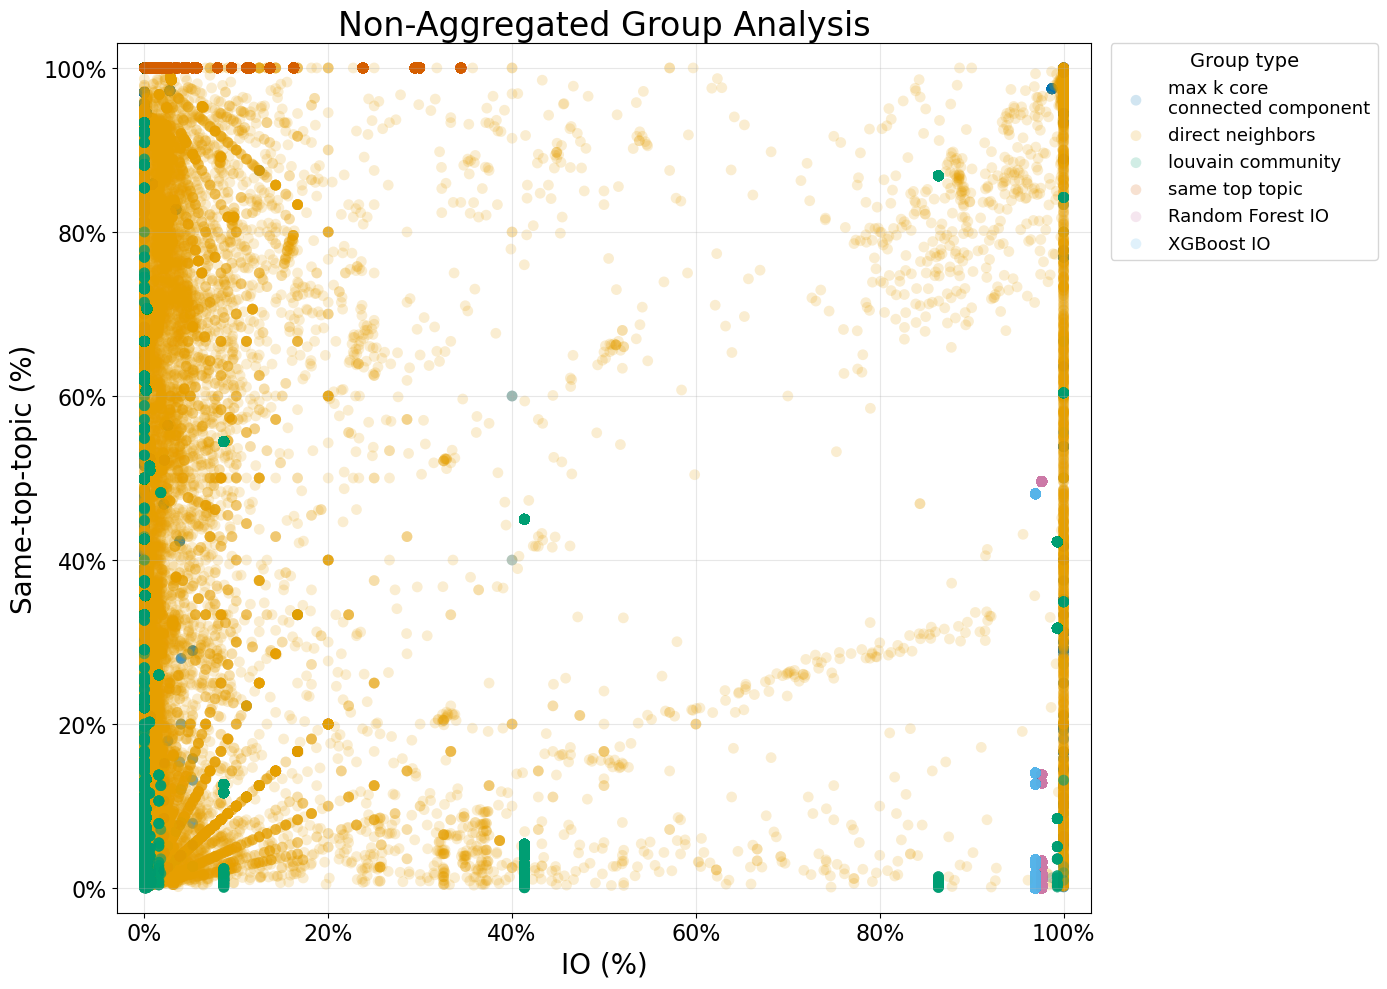

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_aggregate_scatter.png


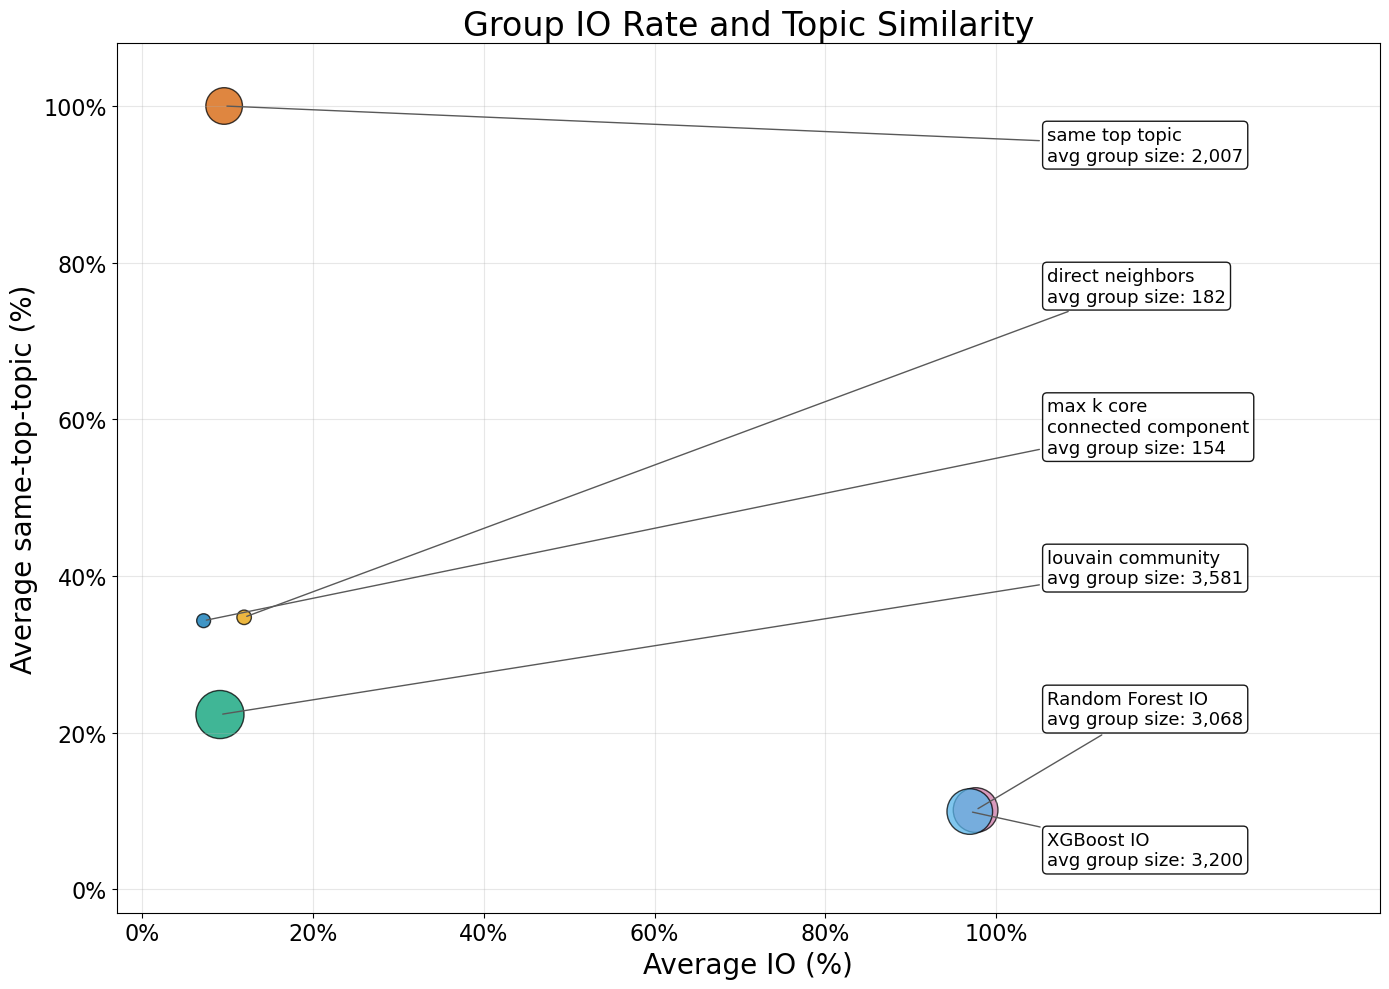

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/all_nodes_group_analysis_combined_scatter.png


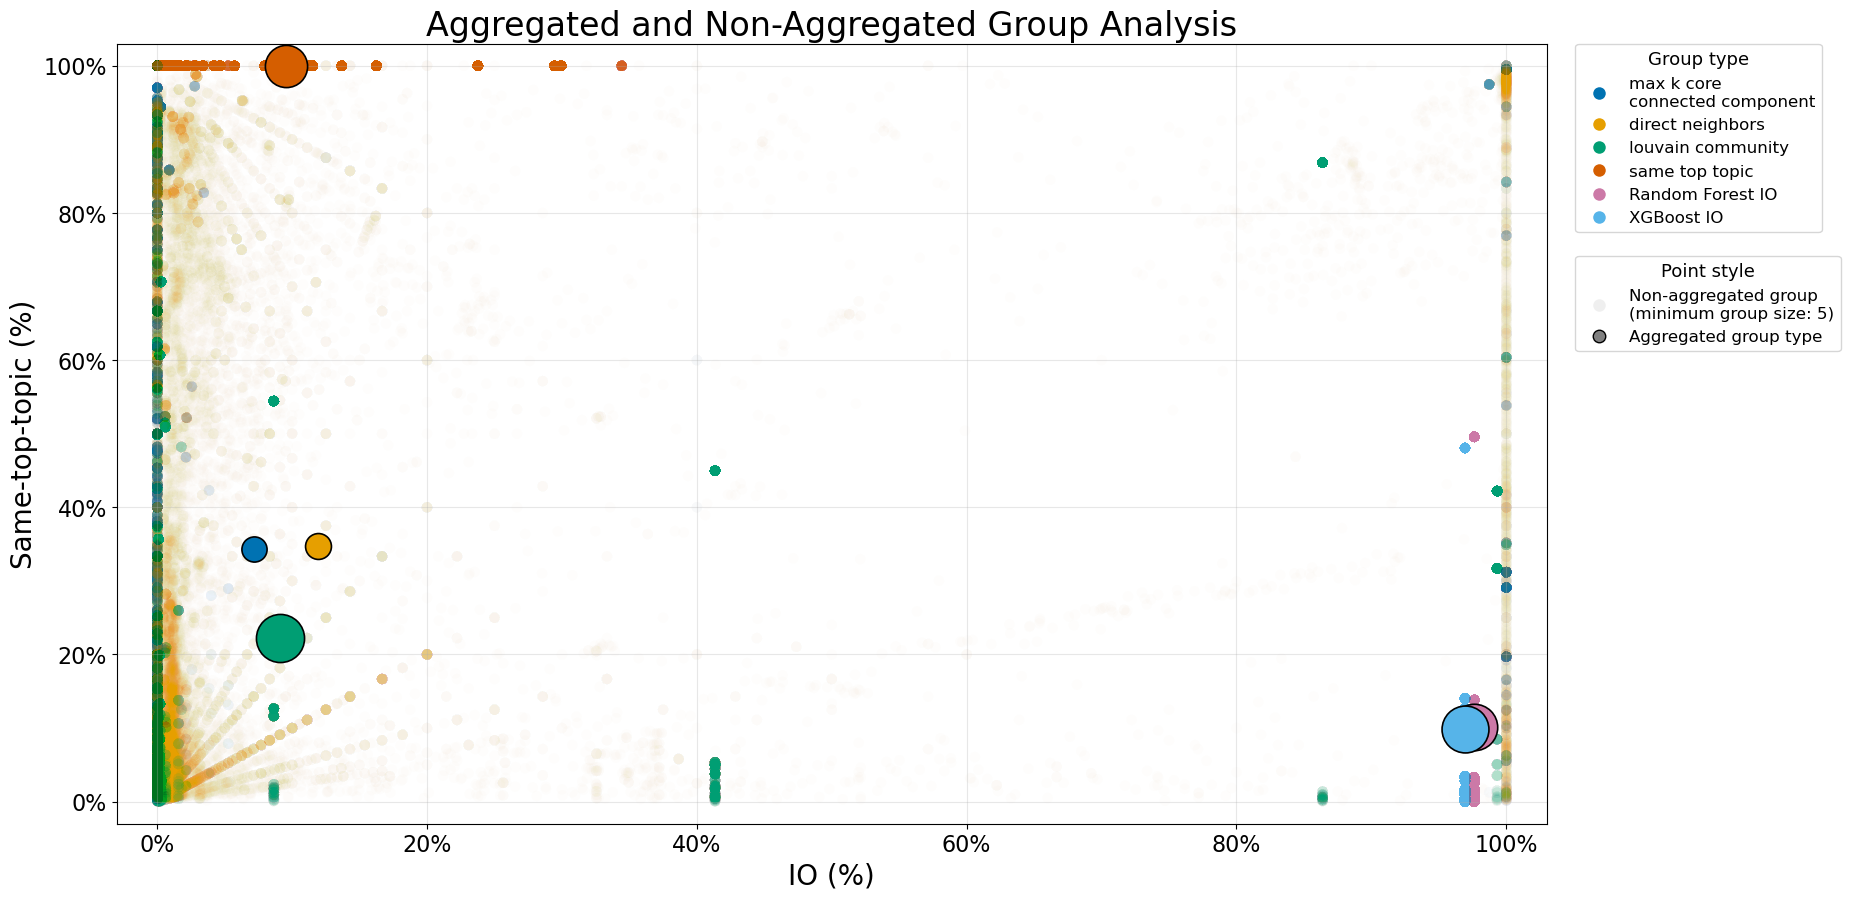

Completed: aggregate_and_plot_group_analysis


In [13]:
group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=all_node_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="all_nodes",
)

### Random Forest predicted-IO authors

Starting build_group_analysis: requested_accounts=3,068, graph_nodes=34,592, classifier_models=1
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 433/433 [00:04<00:00, 95.13core/s] 


[build_group_analysis] Calculating structural and classifier groups for 3,068 accounts


Calculating account groups: 100%|██████████| 3068/3068 [00:05<00:00, 577.20account/s]


Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,00005db7f8a79344f98f5f974c3153af3181be731e,maximal_k_core_component,core=177|component=00005db7f8a79344f98f5f974c3...,1,100.000000,100.000000
1,00005db7f8a79344f98f5f974c3153af3181be731e,direct_neighbors,account=00005db7f8a79344f98f5f974c3153af3181be...,179,100.000000,98.324022
2,00005db7f8a79344f98f5f974c3153af3181be731e,louvain_community,community=420,1307,86.381025,86.840092
3,00005db7f8a79344f98f5f974c3153af3181be731e,same_top_topic,topic=1,5257,29.446452,100.000000
4,00005db7f8a79344f98f5f974c3153af3181be731e,classifier_predicted_io_random_forest,classifier_io|model=random_forest,3068,97.620600,49.576271


Completed: build_group_analysis
Starting aggregate_and_plot_group_analysis: rows=15,340, eligible_rows=13,805, group_types=5, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,direct_neighbors,2854,608.546251,97.006196,57.811098
1,louvain_community,12,1401.607700,74.368472,48.937915
2,same_top_topic,44,3478.670768,23.057739,100.000000
3,classifier_predicted_io_random_forest,1,3068.000000,97.620600,29.108579
4,maximal_k_core_component,42,504.068239,99.486036,62.447852


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_non_aggregated_scatter.png


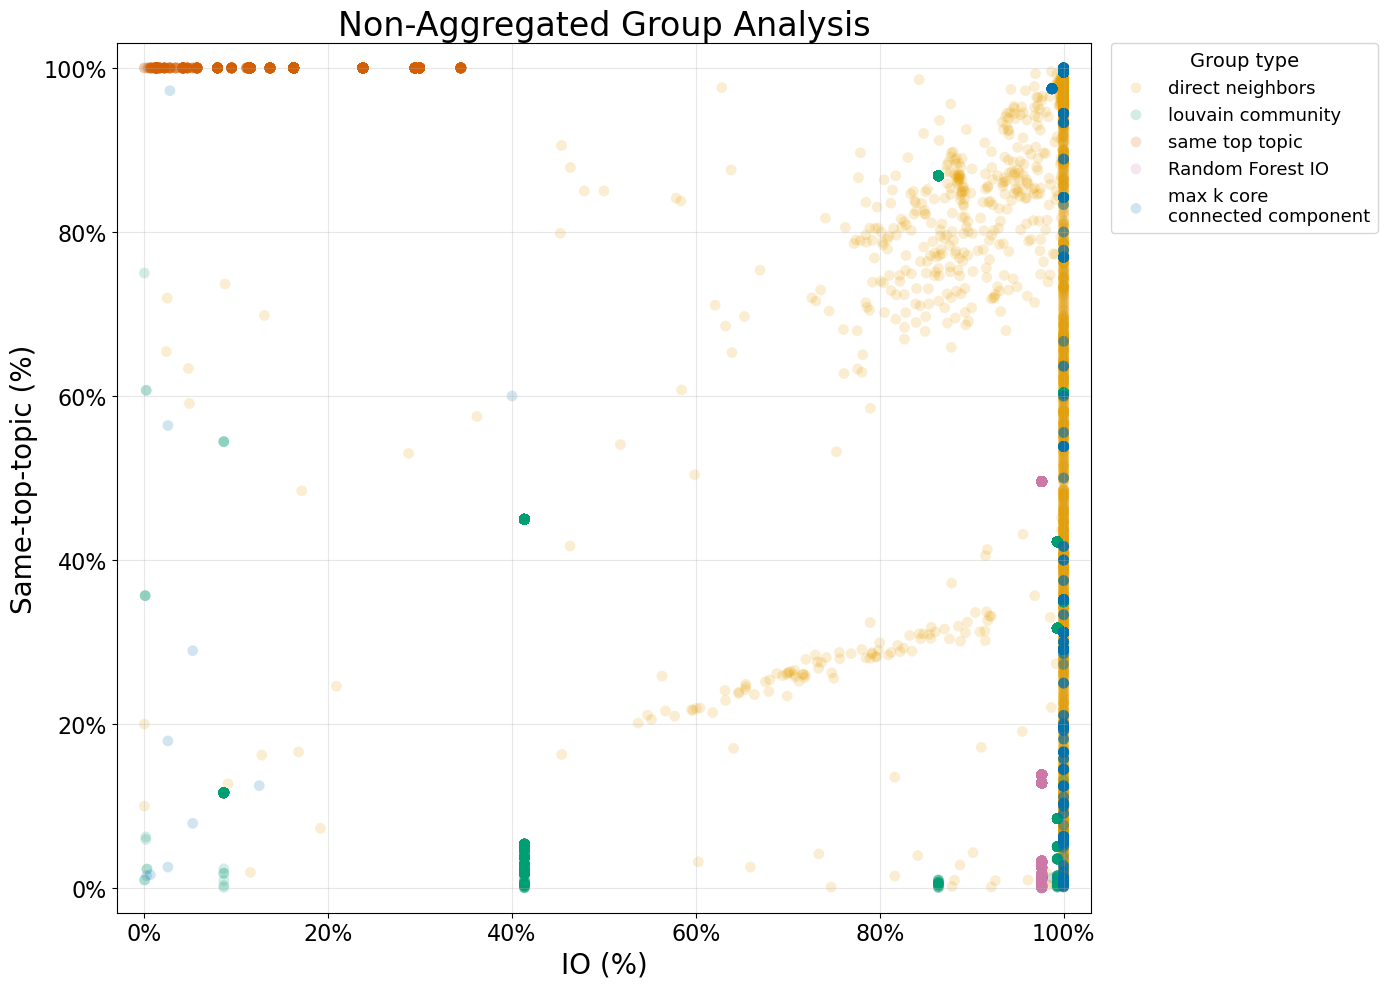

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_aggregate_scatter.png


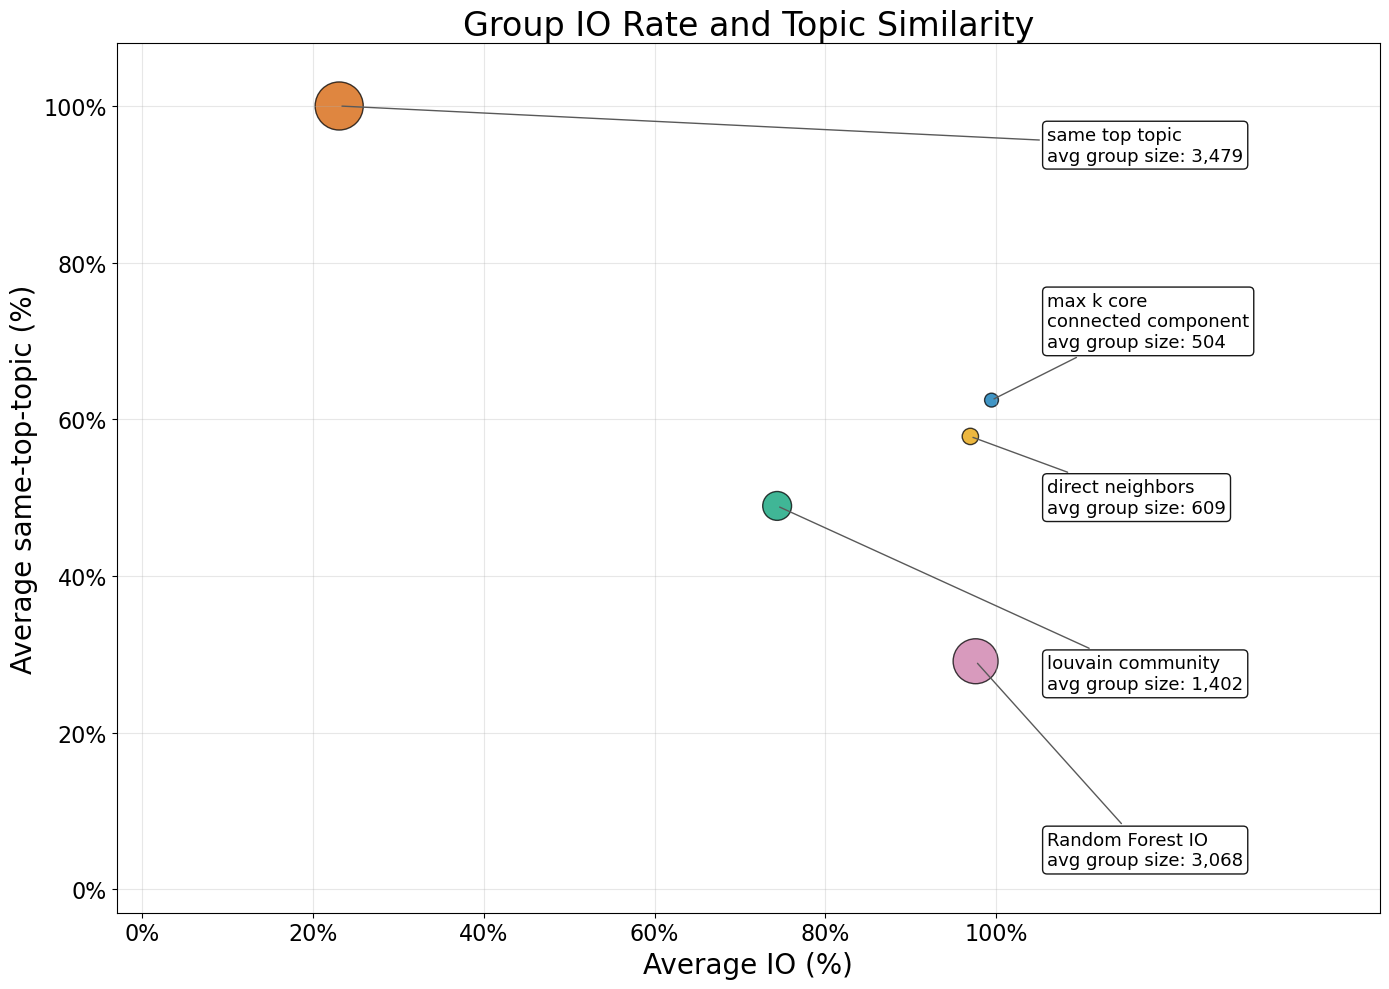

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/rf_io_authors_group_analysis_combined_scatter.png


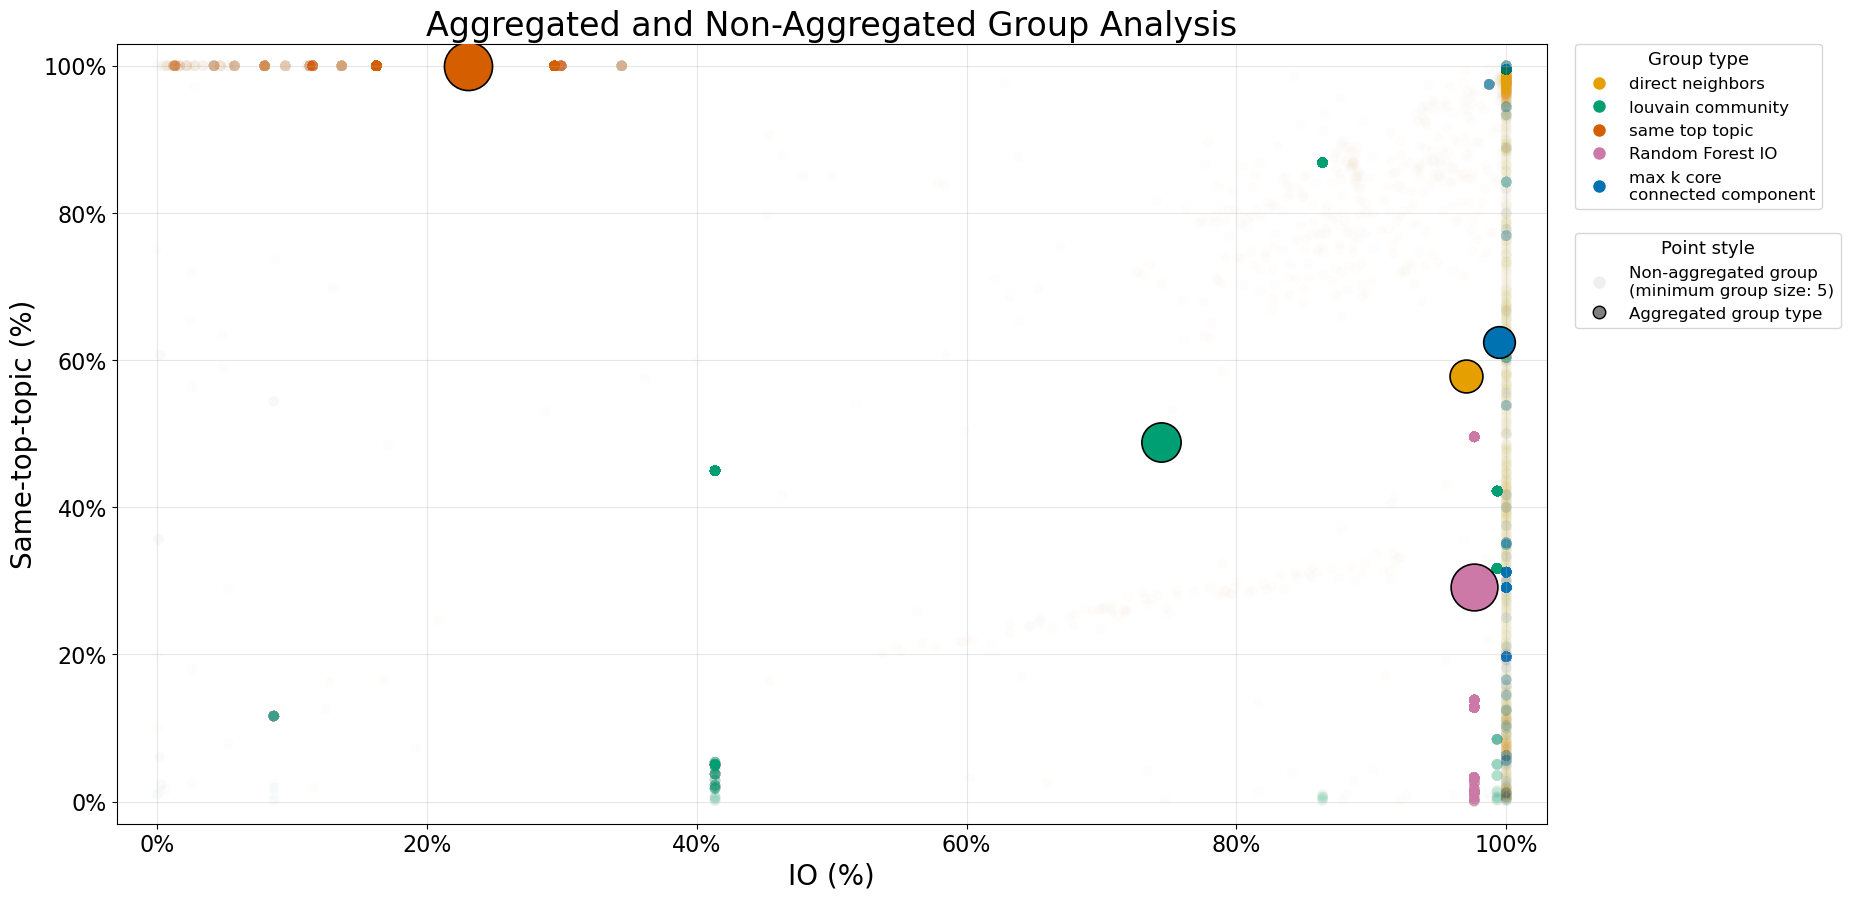

Completed: aggregate_and_plot_group_analysis


In [14]:
rf_io_authors_group_analysis_df = build_group_analysis(
    nodes=classifier_io_authors_by_model["random_forest"],
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model={
        "random_forest": classifier_io_authors_by_model["random_forest"]
    },
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="rf_io_authors_group_analysis_results.csv",
)

rf_io_authors_group_analysis_aggregate_df = aggregate_and_plot_group_analysis(
    group_analysis_df=rf_io_authors_group_analysis_df,
    output_path=group_analysis_folder_path,
    file_name_prefix="rf_io_authors",
)

### XGBoost predicted-IO authors

Starting build_group_analysis: requested_accounts=3,200, graph_nodes=34,592, classifier_models=1
[build_group_analysis] Resolving topic and community attributes
[build_group_analysis] Building requested topic and community groups
[build_group_analysis] Computing core numbers


Finding requested k-core groups: 100%|██████████| 438/438 [00:04<00:00, 87.69core/s] 


[build_group_analysis] Calculating structural and classifier groups for 3,200 accounts


Calculating account groups: 100%|██████████| 3200/3200 [00:05<00:00, 587.78account/s]


Saved group analysis results to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_results.csv


,accountid,group_type,group_id,number_of_nodes,io_percentage,same_top_topic_percentage
0,00005db7f8a79344f98f5f974c3153af3181be731e,maximal_k_core_component,core=177|component=00005db7f8a79344f98f5f974c3...,1,100.000000,100.000000
1,00005db7f8a79344f98f5f974c3153af3181be731e,direct_neighbors,account=00005db7f8a79344f98f5f974c3153af3181be...,179,100.000000,98.324022
2,00005db7f8a79344f98f5f974c3153af3181be731e,louvain_community,community=420,1307,86.381025,86.840092
3,00005db7f8a79344f98f5f974c3153af3181be731e,same_top_topic,topic=1,5257,29.446452,100.000000
4,00005db7f8a79344f98f5f974c3153af3181be731e,classifier_predicted_io_xgboost,classifier_io|model=xgboost,3200,96.937500,48.062500


Completed: build_group_analysis
Starting aggregate_and_plot_group_analysis: rows=16,000, eligible_rows=14,330, group_types=5, min_group_size=5
Saved aggregate group analysis to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_aggregate.csv


,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,direct_neighbors,2965,587.025632,96.481836,57.049098
1,louvain_community,14,1427.085212,73.216613,47.723494
2,same_top_topic,47,3408.718879,22.639429,100.000000
3,classifier_predicted_io_xgboost,1,3200.000000,96.937500,27.632074
4,maximal_k_core_component,50,500.687251,98.895435,62.185526


Saved non-aggregated group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_non_aggregated_scatter.png


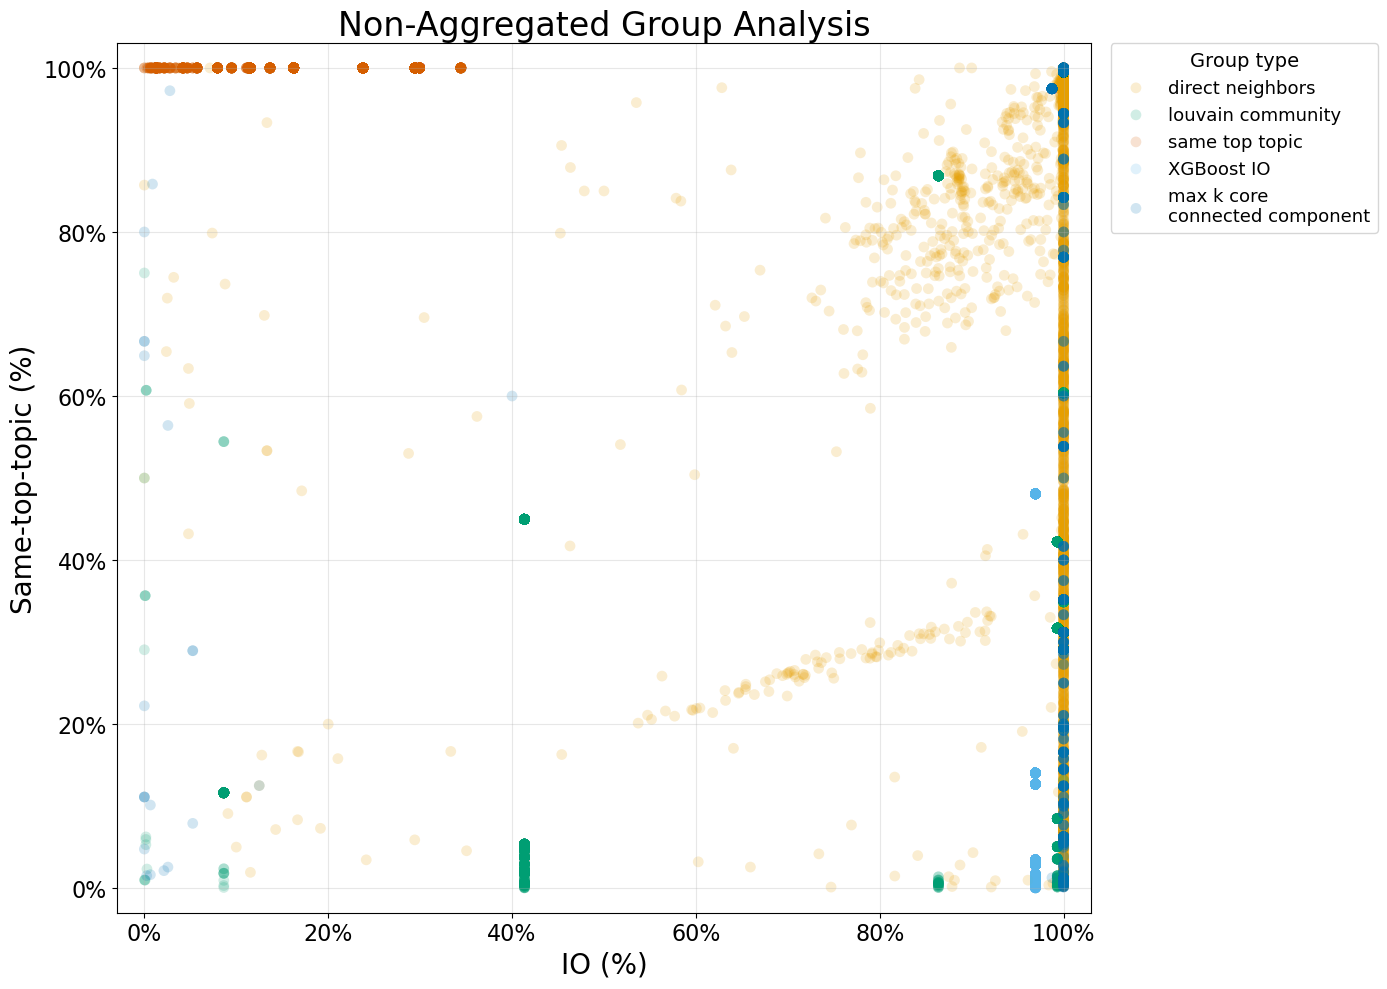

Saved aggregate group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_aggregate_scatter.png


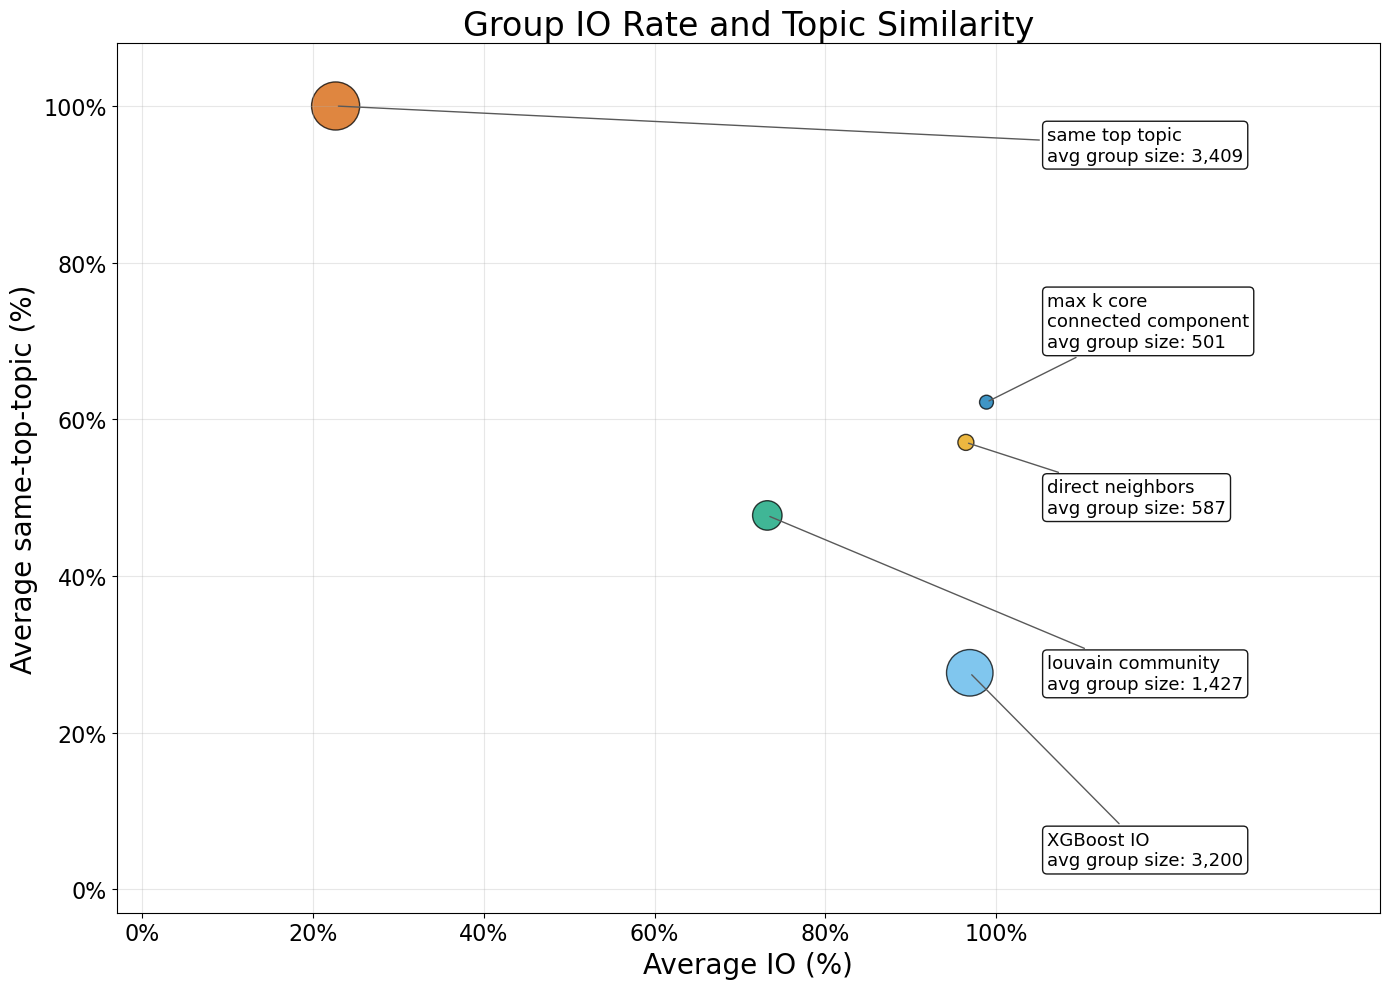

Saved combined group analysis plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/xgb_io_authors_group_analysis_combined_scatter.png


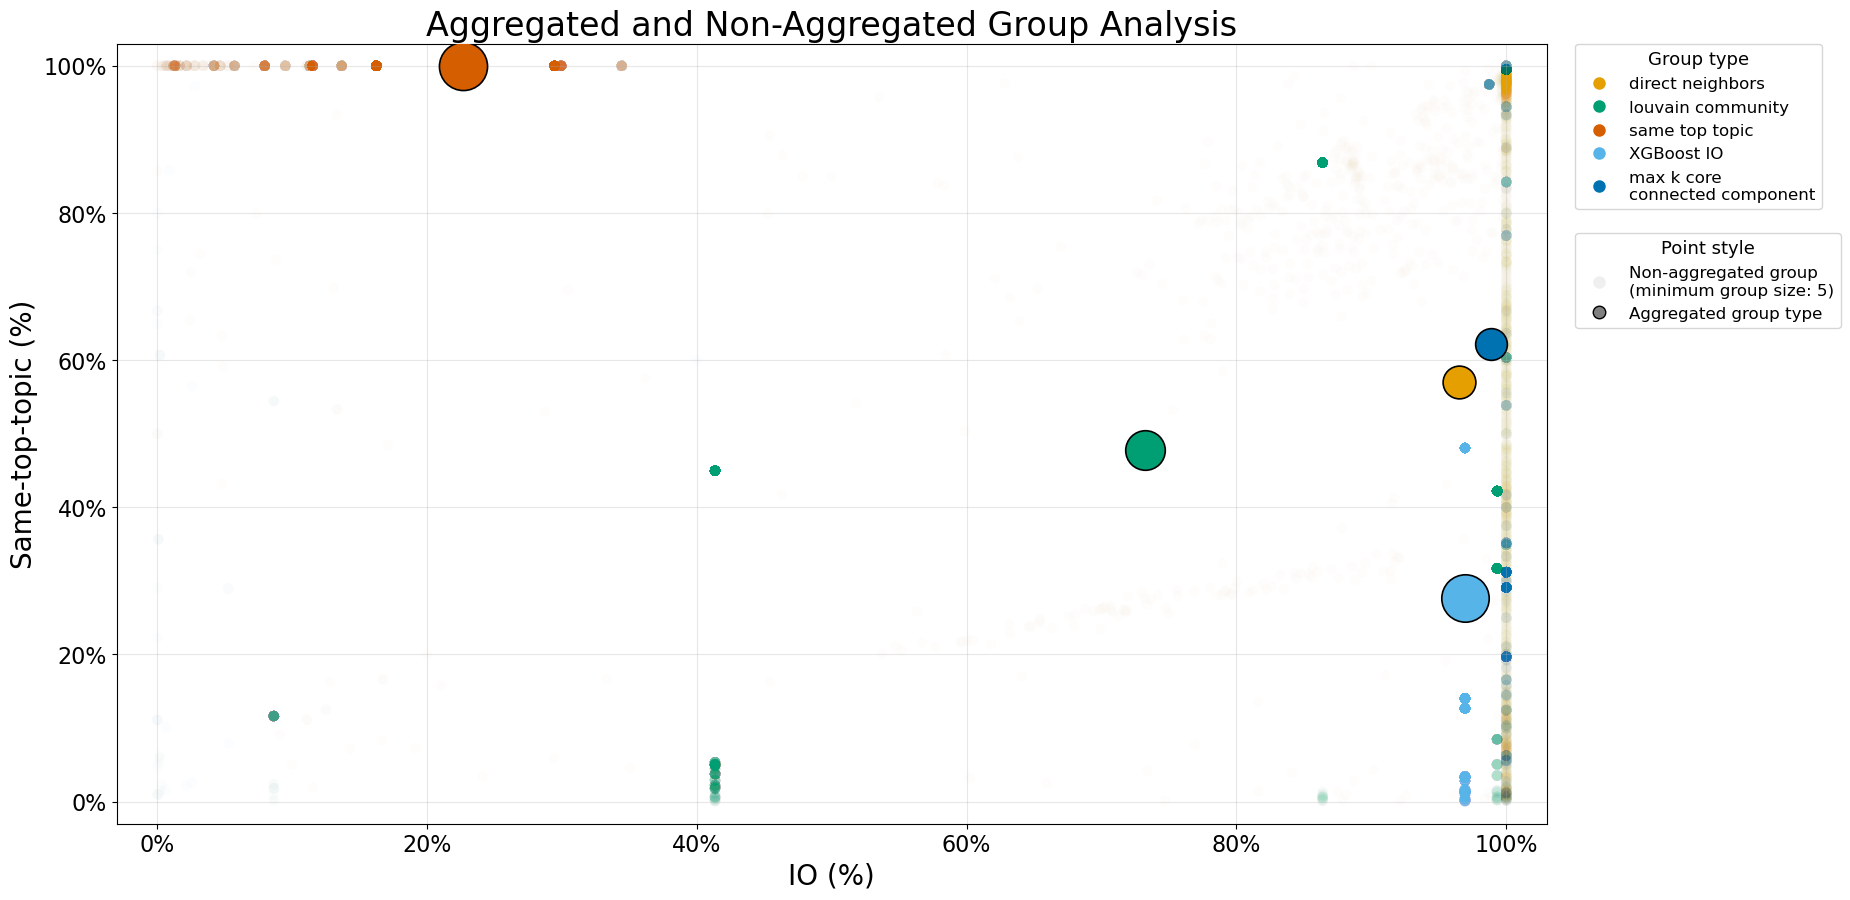

Completed: aggregate_and_plot_group_analysis


In [15]:
xgb_io_authors_group_analysis_df = build_group_analysis(
    nodes=classifier_io_authors_by_model["xgboost"],
    G=G_accounts,
    io_authors_set=io_authors_set,
    classifier_io_authors_by_model={
        "xgboost": classifier_io_authors_by_model["xgboost"]
    },
    node_indicators_df=node_indicators_df,
    output_path=group_analysis_folder_path,
    output_filename="xgb_io_authors_group_analysis_results.csv",
)

xgb_io_authors_group_analysis_aggregate_df = (
    aggregate_and_plot_group_analysis(
        group_analysis_df=xgb_io_authors_group_analysis_df,
        output_path=group_analysis_folder_path,
        file_name_prefix="xgb_io_authors",
    )
)

## Multiple Campaigns Plots

In [16]:
# params
campaigns_names_lst = ["Iran_1", "UAE", "Venezuela", "China_1", "Cuba", "Russia_1"]
model_name = "xgb"

In [30]:
def plot_multiple_campaign_group_analysis(
    campaigns_names_lst: list[str],
    model_name: str,
    project_root: str | Path,
    topic_col: str = "BERTopic_topic_256",
    top_percentage: int | float = 100,
    output_path: str | Path | None = None,
) -> pd.DataFrame:
    """Load, combine, export, and plot campaign group aggregates.

    Args:
        campaigns_names_lst: Campaign result-folder names to compare.
        model_name: Classifier name. Supported aliases are ``random_forest``,
            ``rf``, ``xgboost``, and ``xgb``.
        project_root: Backbone-Graph project root.
        topic_col: Topic column used to create the Step 3 results.
        top_percentage: Top-author percentage used in Step 3.
        output_path: Folder for the LaTeX table and combined plot. Defaults
            to ``src/temp/results``.

    Returns:
        Concatenated model-IO-author and all-author aggregate results.

    Raises:
        ValueError: If no campaigns are supplied or the model is unsupported.
        FileNotFoundError: If an expected aggregate CSV does not exist.
    """
    from matplotlib.lines import Line2D
    from matplotlib.ticker import PercentFormatter

    if not campaigns_names_lst:
        raise ValueError("campaigns_names_lst must contain at least one campaign.")

    model_aliases = {
        "random_forest": ("rf", "Random Forest"),
        "rf": ("rf", "Random Forest"),
        "xgboost": ("xgb", "XGBoost"),
        "xgb": ("xgb", "XGBoost"),
    }
    normalized_model_name = model_name.lower()
    if normalized_model_name not in model_aliases:
        raise ValueError(
            f"Unsupported model_name {model_name!r}. Use one of "
            f"{sorted(model_aliases)}."
        )
    model_prefix, model_label = model_aliases[normalized_model_name]

    project_root = Path(project_root)
    output_path = (
        Path(output_path)
        if output_path is not None
        else project_root / "src" / "temp" / "results"
    )
    output_path.mkdir(parents=True, exist_ok=True)

    author_sets = [
        (f"{model_prefix}_io_authors", f"{model_label} IO Drivers"),
        ("all_nodes", "All authors"),
    ]
    campaign_frames = []
    for campaign_name in campaigns_names_lst:
        group_analysis_path = (
            project_root
            / "results"
            / "Labeled_Datasets"
            / campaign_name
            / f"{campaign_name}_part_all"
            / "step_3_key_authors_graph"
            / f"topic_col_{topic_col}_top_percentage_{top_percentage:g}"
            / "group_analysis"
        )
        for file_prefix, author_set_label in author_sets:
            aggregate_path = (
                group_analysis_path
                / f"{file_prefix}_group_analysis_aggregate.csv"
            )
            if not aggregate_path.is_file():
                raise FileNotFoundError(
                    f"Missing aggregate CSV for {campaign_name}: {aggregate_path}"
                )
            campaign_df = pd.read_csv(aggregate_path)
            campaign_df.insert(0, "Author set", author_set_label)
            campaign_df.insert(0, "Campaign name", campaign_name)
            campaign_frames.append(campaign_df)

    combined_df = pd.concat(campaign_frames, ignore_index=True)
    latex_df = combined_df.copy()
    numeric_columns = latex_df.select_dtypes(include="number").columns
    latex_df[numeric_columns] = latex_df[numeric_columns].round().astype("Int64")
    latex_path = output_path / f"{model_prefix}_multiple_campaign_group_analysis.tex"
    latex_df.to_latex(latex_path, index=False, escape=True)
    print(f"Saved multiple-campaign LaTeX table to: {latex_path}")

    fixed_group_colors = {
        "maximal_k_core_component": "#0072B2",
        "direct_neighbors": "#E69F00",
        "louvain_community": "#009E73",
        "same_top_topic": "#D55E00",
        "classifier_predicted_io": "#CC79A7",
        "classifier_predicted_io_random_forest": "#CC79A7",
        "classifier_predicted_io_xgboost": "#56B4E9",
    }
    group_types = list(combined_df["group_type"].drop_duplicates())
    fallback_colors = plt.get_cmap("tab10").colors
    group_colors = {
        group_type: fixed_group_colors.get(
            group_type, fallback_colors[index % len(fallback_colors)]
        )
        for index, group_type in enumerate(group_types)
    }

    number_of_campaigns = len(campaigns_names_lst)
    fig, axes = plt.subplots(
        2,
        number_of_campaigns,
        figsize=(6 * number_of_campaigns, 13),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    maximum_group_size = combined_df["average_number_of_nodes"].max()
    for row_index, (_, author_set_label) in enumerate(author_sets):
        for column_index, campaign_name in enumerate(campaigns_names_lst):
            ax = axes[row_index, column_index]
            plot_df = combined_df.loc[
                combined_df["Campaign name"].eq(campaign_name)
                & combined_df["Author set"].eq(author_set_label)
            ].dropna(
                subset=[
                    "average_io_percentage",
                    "average_same_top_topic_percentage",
                    "average_number_of_nodes",
                ]
            )
            marker_sizes = 140 + 760 * (
                np.log1p(plot_df["average_number_of_nodes"])
                / np.log1p(maximum_group_size)
            )
            ax.scatter(
                plot_df["average_io_percentage"],
                plot_df["average_same_top_topic_percentage"],
                s=marker_sizes,
                c=[group_colors[value] for value in plot_df["group_type"]],
                alpha=0.8,
                edgecolors="black",
                linewidths=1,
            )
            ax.set_xlim(-5, 105)
            ax.set_ylim(-5, 105)
            ax.set_xticks(np.arange(0, 101, 25))
            ax.set_yticks(np.arange(0, 101, 25))
            ax.xaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
            ax.yaxis.set_major_formatter(PercentFormatter(xmax=100, decimals=0))
            ax.tick_params(axis="both", labelsize=22)
            ax.grid(alpha=0.3)
            if row_index == 0:
                ax.set_title(
                    campaign_name.replace("_", " "),
                    fontsize=28,
                )
            if column_index == 0:
                bold_author_set_label = (
                    r"$\bf{"
                    + author_set_label.replace(" ", r"\ ")
                    + r"}$"
                )
                ax.set_ylabel(
                    f"{bold_author_set_label}\nSame-top-topic (%)",
                    fontsize=25,
                )
            if row_index == 1:
                ax.set_xlabel(
                    "IO (%)",
                    fontsize=25,
                )

    def format_group_label(group_type: str) -> str:
        """Convert a stored group identifier to a readable legend label.

        Args:
            group_type: Group identifier from an aggregate CSV.

        Returns:
            Human-readable group label.
        """
        labels = {
            "maximal_k_core_component": "Max k-core component",
            "direct_neighbors": "Direct neighbors",
            "louvain_community": "Louvain community",
            "same_top_topic": "Same top topic",
            "classifier_predicted_io": "Classifier-predicted IO",
            "classifier_predicted_io_random_forest": "Random Forest IO",
            "classifier_predicted_io_xgboost": "XGBoost IO",
        }
        return labels.get(group_type, group_type.replace("_", " "))

    legend_handles = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="none",
            markerfacecolor=group_colors[group_type],
            markeredgecolor="black",
            markersize=17,
            label=format_group_label(group_type),
        )
        for group_type in group_types
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=len(legend_handles),
        fontsize=28,
        bbox_to_anchor=(0.5, 0.01),
    )
    fig.suptitle(
        f"Group Analysis Across Campaigns ({model_label})",
        fontsize=38,
    )
    fig.tight_layout(rect=(0, 0.09, 1, 0.93))
    plot_path = output_path / f"{model_prefix}_multiple_campaign_group_analysis.png"
    fig.savefig(plot_path, dpi=450, bbox_inches="tight")
    print(f"Saved multiple-campaign plot to: {plot_path}")
    plt.show()
    plt.close(fig)

    display(combined_df)
    return combined_df

Saved multiple-campaign LaTeX table to: /home/amitner/Backbone-Graph/src/temp/results/xgb_multiple_campaign_group_analysis.tex


Saved multiple-campaign plot to: /home/amitner/Backbone-Graph/src/temp/results/xgb_multiple_campaign_group_analysis.png


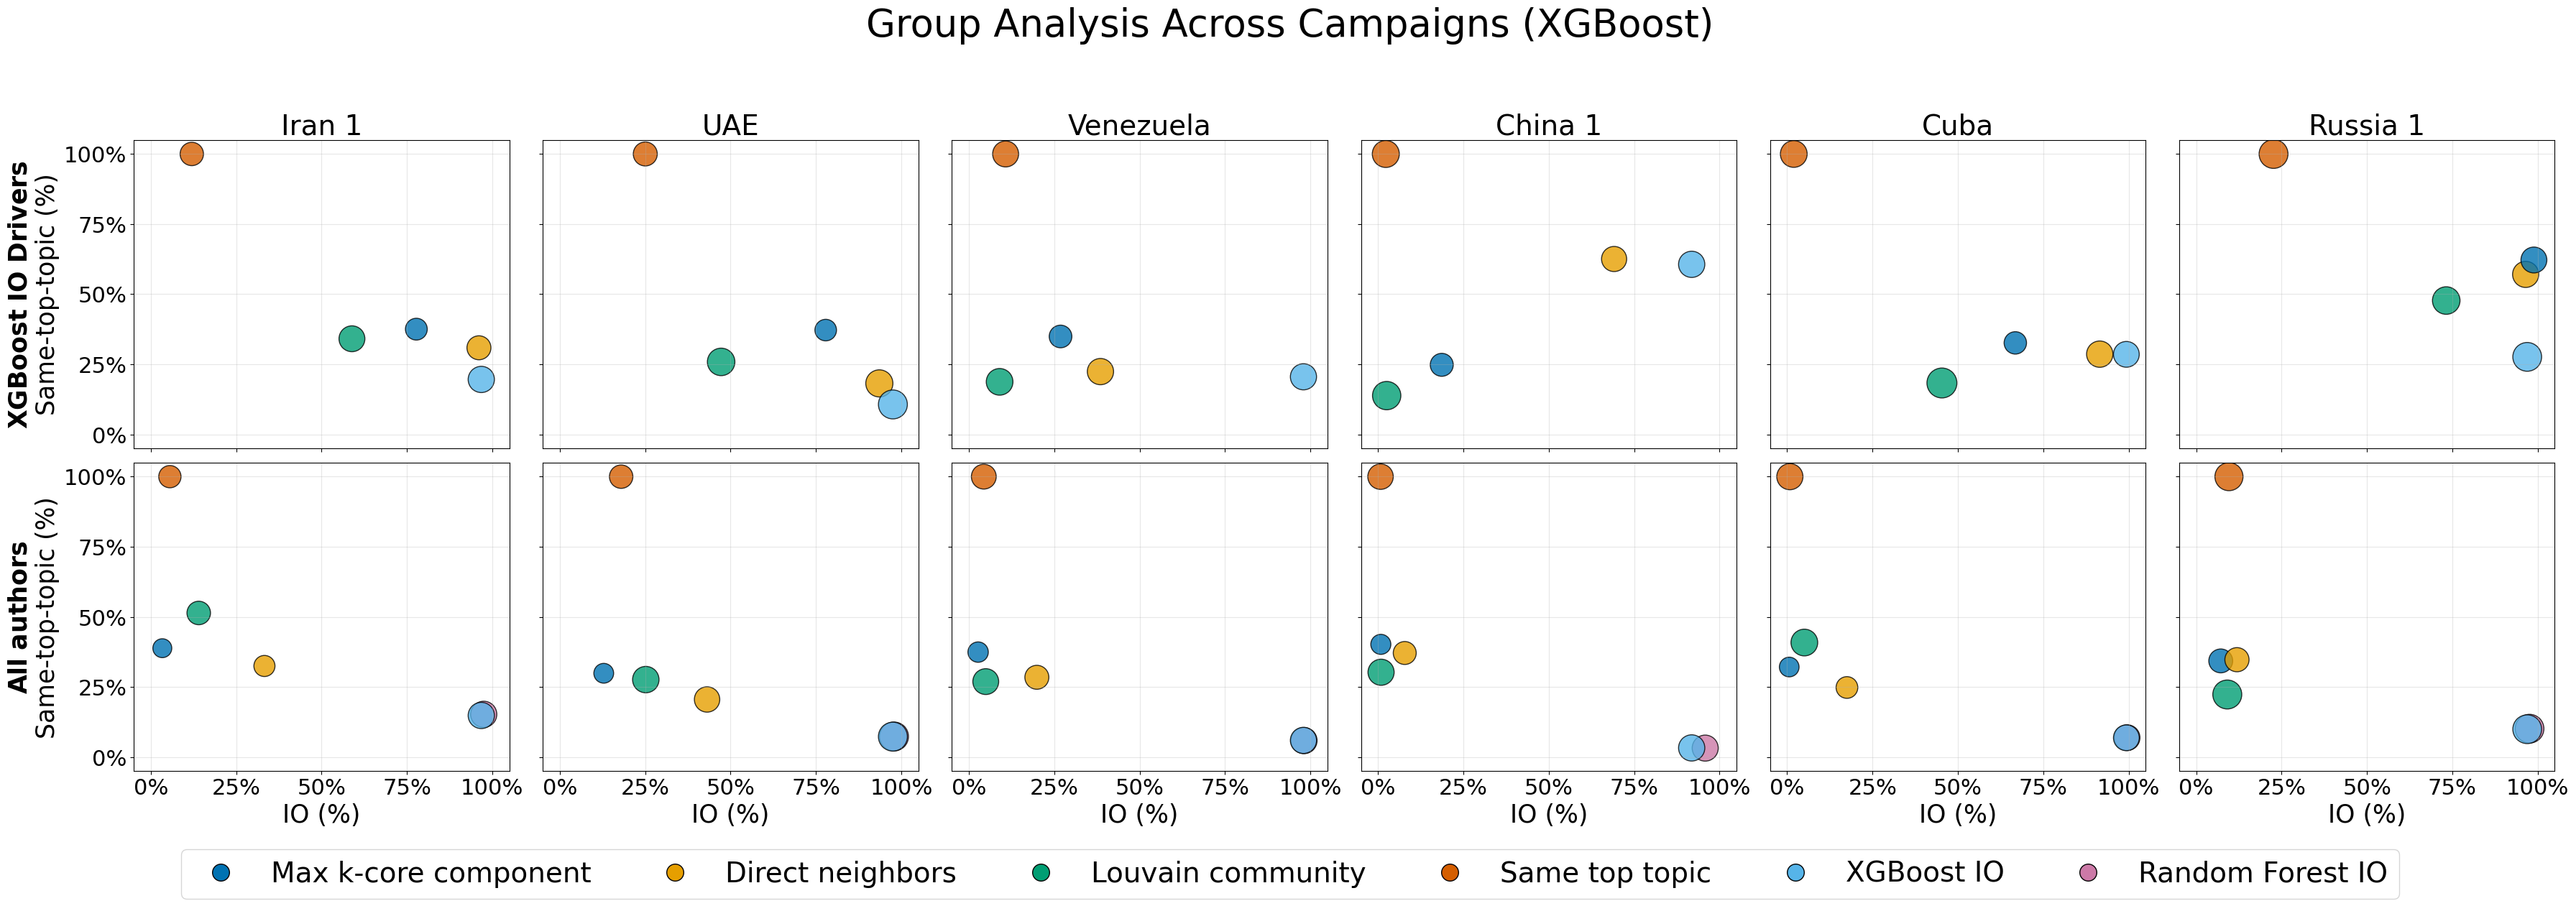

,Campaign name,Author set,group_type,number_of_unique_groups,average_number_of_nodes,average_io_percentage,average_same_top_topic_percentage
0,Iran_1,XGBoost IO Drivers,maximal_k_core_component,9,50.888889,77.777778,37.514010
1,Iran_1,XGBoost IO Drivers,direct_neighbors,587,164.126065,96.109867,30.873998
2,Iran_1,XGBoost IO Drivers,louvain_community,10,499.700000,58.910776,34.090100
3,Iran_1,XGBoost IO Drivers,same_top_topic,37,115.918919,12.005648,100.000000
4,Iran_1,XGBoost IO Drivers,classifier_predicted_io_xgboost,1,625.000000,96.800000,19.581498
...,...,...,...,...,...,...,...
61,Russia_1,All authors,direct_neighbors,33423,181.646471,11.921345,34.716359
62,Russia_1,All authors,louvain_community,90,3580.636876,9.089841,22.304610
63,Russia_1,All authors,same_top_topic,74,2007.186422,9.579010,100.000000
64,Russia_1,All authors,classifier_predicted_io_random_forest,1,3068.000000,97.620600,10.107330


In [31]:
multiple_campaign_group_analysis_df = plot_multiple_campaign_group_analysis(
    campaigns_names_lst=campaigns_names_lst,
    model_name=model_name,
    project_root=project_root,
)

## Analyze Group Topics

In [19]:
top_core_authors_df = get_top_authors_by_indicator(
    node_indicators_df,
    indicator_col="core_number",
    n=10,
)
top_core_user = top_core_authors_df.index[0]

core_numbers = nx.core_number(G_accounts)
top_core_user_k_core_nodes = get_node_k_core(
    node_id=top_core_user,
    G=G_accounts,
    core_numbers=core_numbers,
    include_node=False,
)

print(top_core_user_k_core_nodes)

Starting get_top_authors_by_indicator: authors=34,592, indicator_col=core_number, top_n=10
keep is set to 'first', meaning: prioritize the first occurrences when values are tied.
Completed: get_top_authors_by_indicator
Starting get_node_k_core: node_id=002274eeaf5d65a4faa12ddc11d3b464e706bdd6d9, nodes=34,592, include_node=False
[get_node_k_core] Node '002274eeaf5d65a4faa12ddc11d3b464e706bdd6d9' is in k-core 726 with 799 nodes.
{'...'}


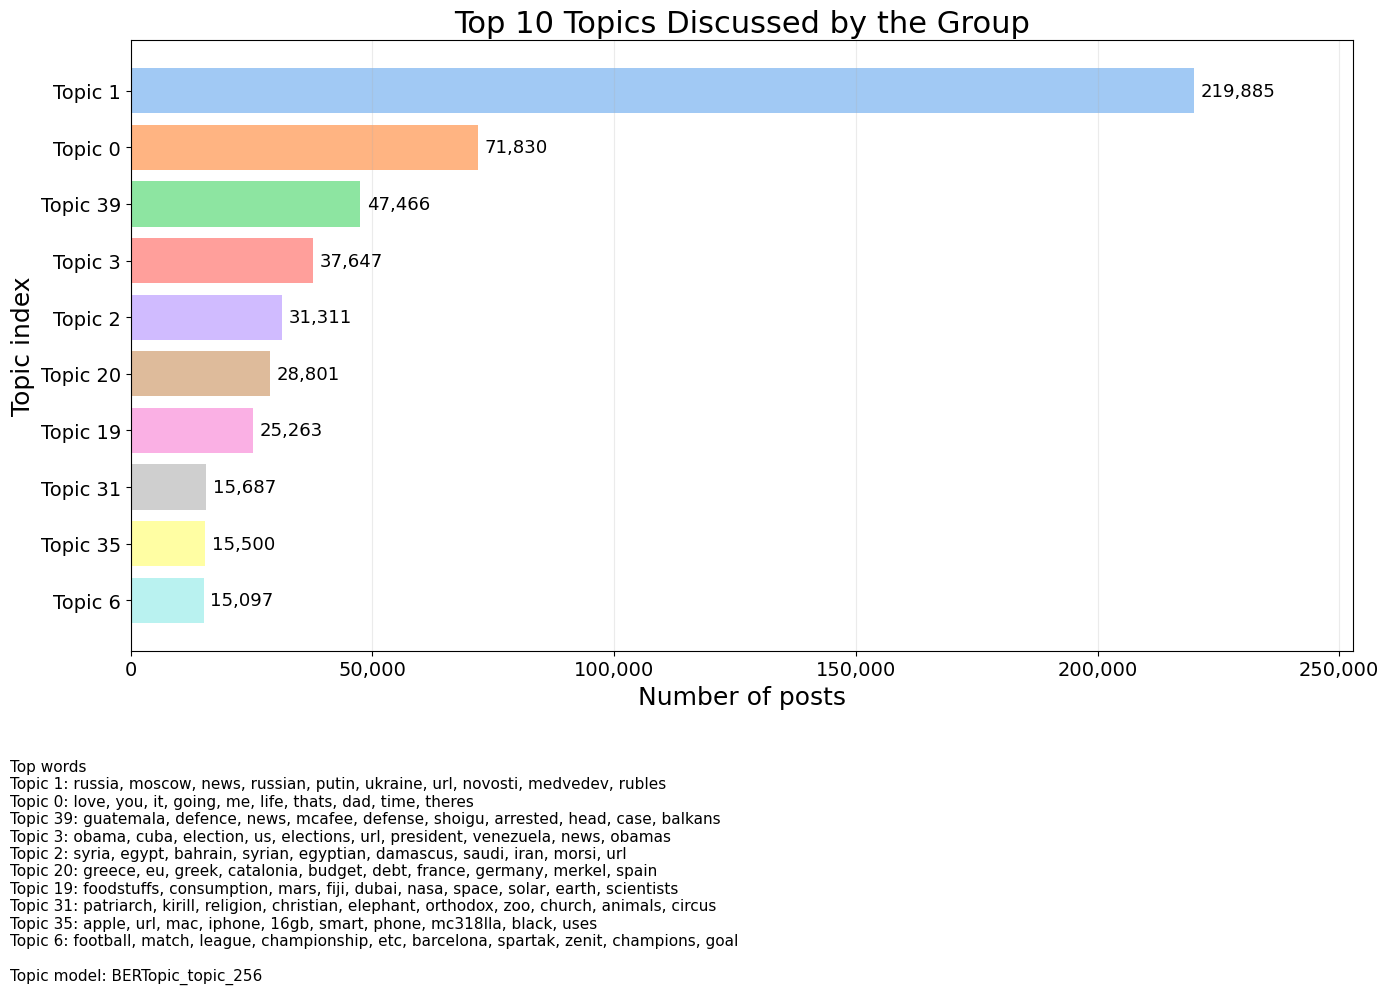

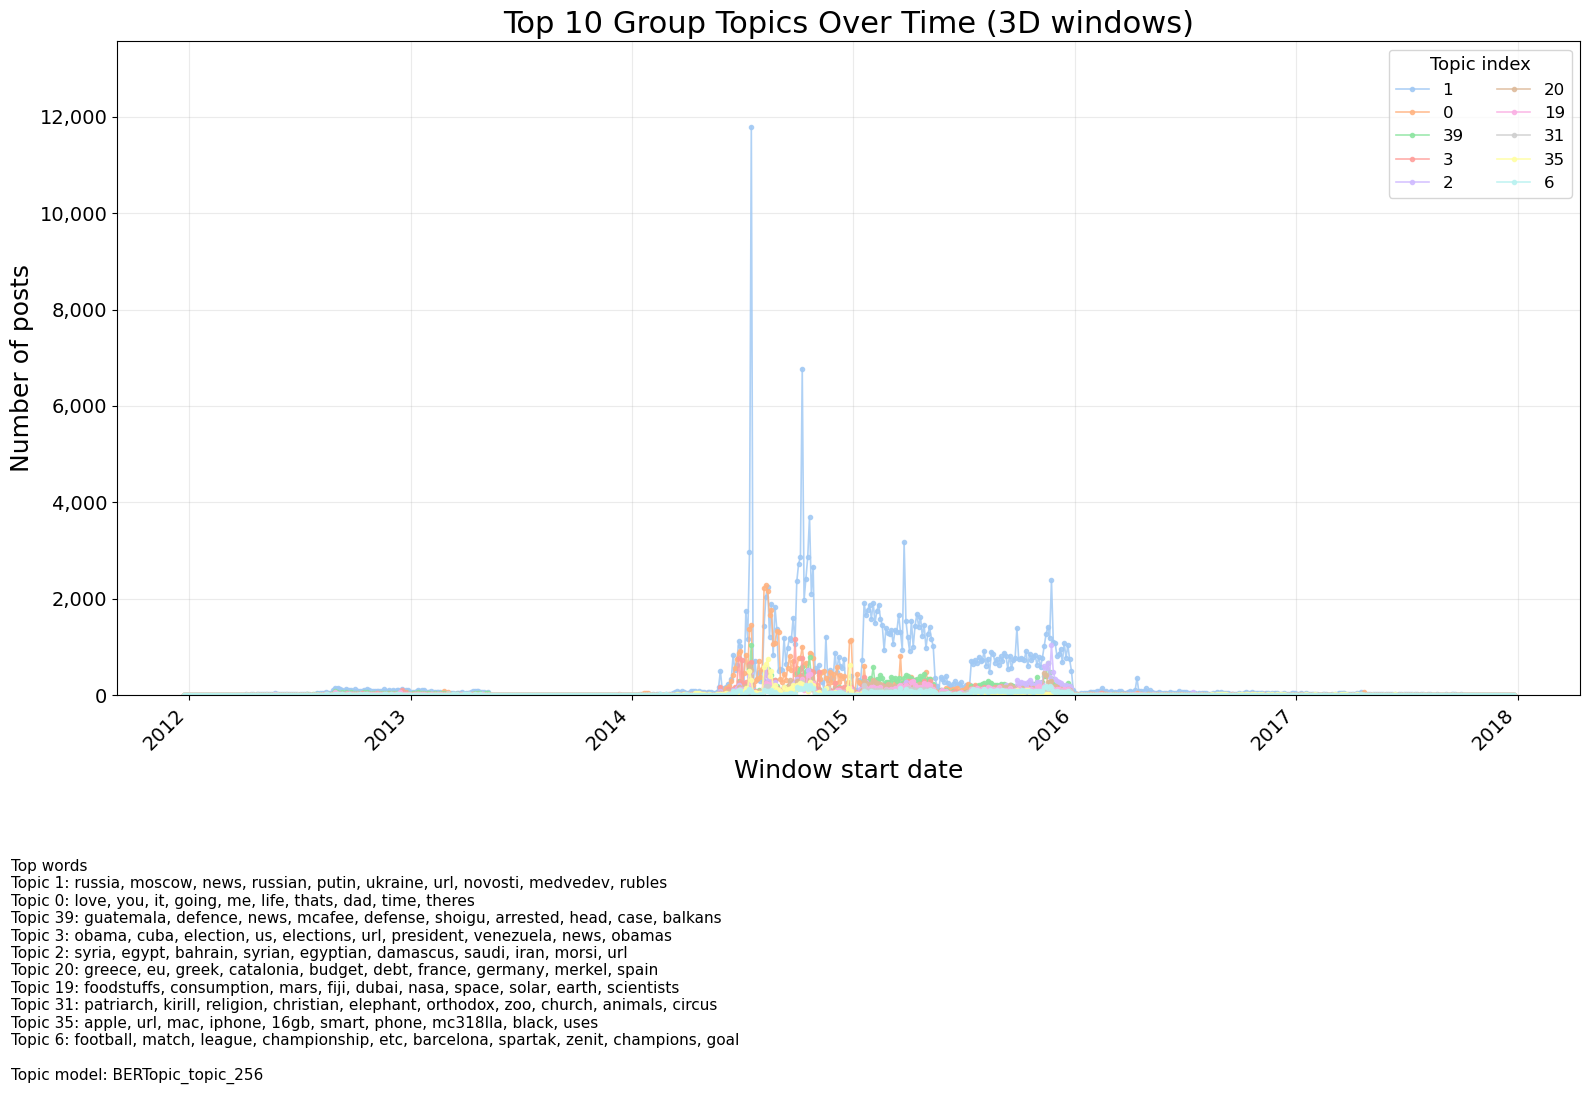

Saved temporal topic counts to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topic_counts_BERTopic_topic_256_3D.csv
Saved topic distribution plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topic_distribution_BERTopic_topic_256.png
Saved temporal topic plot to: /home/amitner/Backbone-Graph/results/Labeled_Datasets/Russia_1/Russia_1_part_all/step_3_key_authors_graph/topic_col_BERTopic_topic_256_top_percentage_100/group_analysis/top_core_user_k_core_group_topics/group_topics_over_time_BERTopic_topic_256_3D.png


,start_date,end_date,BERTopic_topic_256,post_count,topic_top_words
0,2011-12-24,2011-12-27,3,1,"obama, cuba, election, us, elections, url, pre..."
1,2011-12-30,2012-01-02,19,1,"foodstuffs, consumption, mars, fiji, dubai, na..."
2,2012-01-02,2012-01-05,0,1,"love, you, it, going, me, life, thats, dad, ti..."
3,2012-01-02,2012-01-05,6,1,"football, match, league, championship, etc, ba..."
4,2012-01-05,2012-01-08,0,1,"love, you, it, going, me, life, thats, dad, ti..."
5,2012-01-05,2012-01-08,14,1,"eat, chicken, drink, cream, cake, chocolate, f..."
6,2012-01-05,2012-01-08,28,1,"videos, twitter, stars, four, fourstar, use, u..."
7,2012-01-08,2012-01-11,6,1,"football, match, league, championship, etc, ba..."
8,2012-01-08,2012-01-11,26,1,"sleep, friday, bed, wake, sleeping, go, asleep..."
9,2012-01-11,2012-01-14,5,1,"user, url, lol, xd, haha, users, yes, twitter,..."


Completed: analyze_group_topics


In [20]:
group_topic_counts_df = analyze_group_topics(
    df=df,
    nodes=top_core_user_k_core_nodes,
    time_window="3D",
    topic_col=topic_col,
    output_path=group_analysis_folder_path / "top_core_user_k_core_group_topics",
)